In [5]:
import pandas as pd

In [9]:
import os
print(os.getcwd())

C:\Users\faith


In [11]:
df = pd.read_csv(r'C:\Users\faith\Downloads\E-commerce Data\data.csv', encoding='latin1')

In [12]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [16]:
rows, cols = df.shape

print(f"Number of rows:{rows}")
print(f"Number of colums: {cols}")

Number of rows:541909
Number of colums: 8


In [21]:
columns_name = df.columns
print(f"columns name ={columns_name}")

columns name =Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [27]:
missing_value = df.isnull().sum()
print(f"Missing values per column: {missing_value}")

print("-" * 30)

most_missing_column = missing_value.idxmax()
print(f"The column with the most missing values is: {most_missing_column}")

Missing values per column: InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
------------------------------
The column with the most missing values is: CustomerID


In [29]:
duplicate_rows = df.duplicated().sum()
print(f"Duplicate rows in the dataset:{duplicate_rows}")

Duplicate rows in the dataset:5268


In [30]:
df[df.duplicated(keep=False)].head(15)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
548,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,12/1/2010 11:49,2.95,17920.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,12/1/2010 11:49,2.95,17920.0,United Kingdom


In [55]:
# 1. Define the columns that make an item unique
group_cols = ['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

# 2. Group by those columns and SUM the quantities
# (dropna=False ensures we don't accidentally lose the rows where CustomerID is blank!)
df_cleaned = df.groupby(group_cols, as_index=False, dropna=False)['Quantity'].sum()

# 3. Check your new row count
print(f"Original row count: {len(df)}")
print(f"Cleaned row count: {len(df_cleaned)}")
print(f"Rows consolidated: {len(df) - len(df_cleaned)}")

Original row count: 541909
Cleaned row count: 531808
Rows consolidated: 10101


In [58]:
# 1. Dynamically read the length of whatever columns are currently in memory
current_len = len(df_cleaned.columns)
print(f"Your DataFrame currently has {current_len} columns.")

# 2. Build a baseline safe map based on your actual column order from the last error screen
# This ensures a perfect 10-element length match no matter what!
df_cleaned.columns = ['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Quantity', 'Month', 'TotalSales'][:current_len]

# 3. Clean them perfectly with the required hint methods
df_cleaned.columns = (df_cleaned.columns.str.lower()
                      .str.replace('no', '-no')
                      .str.replace('code', '-code')
                      .str.replace('date', '-date')
                      .str.replace('price', '-price')
                      .str.replace('id', '-id')
                      .str.replace('sales', '-sales'))

print("\n=== PERFECTLY CLEANED DASH COLUMNS ===")
print(df_cleaned.columns)

Your DataFrame currently has 8 columns.

=== PERFECTLY CLEANED DASH COLUMNS ===
Index(['invoice-no', 'stock-code', 'description', 'invoice-date', 'unit-price',
       'customer-id', 'country', 'quantity'],
      dtype='object')


In [59]:
# 1. Get the raw number of orders per country
order_counts = df_cleaned['country'].value_counts()

# 2. Get the percentage of total orders per country
order_percentages = df_cleaned['country'].value_counts(normalize=True) * 100

# 3. Print the top results cleanly
print("=== TOP 5 COUNTRIES BY ORDER COUNT ===")
print(order_counts.head())
print("\n" + "="*35 + "\n")

print("=== TOP 5 COUNTRIES BY PERCENTAGE OF TOTAL ===")
print(order_percentages.head().round(2).astype(str) + '%')

=== TOP 5 COUNTRIES BY ORDER COUNT ===
country
United Kingdom    485564
Germany             9470
France              8521
EIRE                8181
Spain               2512
Name: count, dtype: int64


=== TOP 5 COUNTRIES BY PERCENTAGE OF TOTAL ===
country
United Kingdom    91.3%
Germany           1.78%
France             1.6%
EIRE              1.54%
Spain             0.47%
Name: proportion, dtype: object


In [60]:
# 1. Group by description and sum the quantities
product_sales = df_cleaned.groupby('description', as_index=False)['quantity'].sum()

# 2. Sort by quantity in descending order to get the highest numbers at the top
top_products = product_sales.sort_values(by='quantity', ascending=False).head(5).reset_index(drop=True)

# 3. Print the results cleanly
print("=== TOP 5 BEST-SELLING PRODUCTS ===")
print(top_products)

=== TOP 5 BEST-SELLING PRODUCTS ===
                         description  quantity
0  WORLD WAR 2 GLIDERS ASSTD DESIGNS     53847
1            JUMBO BAG RED RETROSPOT     47363
2      ASSORTED COLOUR BIRD ORNAMENT     36381
3                     POPCORN HOLDER     36334
4    PACK OF 72 RETROSPOT CAKE CASES     36039


In [62]:
# 1. Force reset the columns to clean names to get rid of the triple underscores
df_cleaned.columns = ['invoice-no', 'stock-code', 'description', 'invoice-date', 'unit-price', 'customer-id', 'country', 'quantity']

# 2. Convert invoice_date to a proper datetime format
df_cleaned['invoice-date'] = pd.to_datetime(df_cleaned['invoice-date'])

# 3. Extract the month number from the clean column
df_cleaned['month'] = df_cleaned['invoice-date'].dt.month

# 4. Create total_sales using the clean column names
df_cleaned['total-sales'] = df_cleaned['quantity'] * df_cleaned['unit-price']

# 5. Group by month and sum the sales revenue
monthly_sales = df_cleaned.groupby('month')['total-sales'].sum().reset_index()

# 6. Sort the results to see highest and lowest clearly
monthly_sales = monthly_sales.sort_values(by='total-sales', ascending=False).reset_index(drop=True)

print("=== MONTHLY SALES REVENUE PERFORMANCE ===")
print(monthly_sales)

=== MONTHLY SALES REVENUE PERFORMANCE ===
    month  total-sales
0      11  1461756.250
1      12  1182625.030
2      10  1070704.670
3       9  1019687.622
4       5   723333.510
5       6   691123.120
6       3   683267.080
7       8   682680.510
8       7   681300.111
9       1   560000.260
10      2   498062.650
11      4   493207.121


In [63]:
# 1. Calculate the revenue for every row in the dataset (using bracket notation for dashes)
df_cleaned['total-sales'] = df_cleaned['quantity'] * df_cleaned['unit-price']

# 2. Group by 'invoice-no' to sum up all items bought within the same order
order_totals = df_cleaned.groupby('invoice-no')['total-sales'].sum()

# 3. Use .describe() as suggested in the hint to see all summary statistics at once
print("=== ORDER VALUE SUMMARY STATISTICS ===")
print(order_totals.describe())

print("\n" + "="*40 + "\n")

# 4. Extract the exact answers explicitly
avg_order_value = order_totals.mean()
max_order_value = order_totals.max()

print(f"Average Order Value: ${avg_order_value:,.2f}")
print(f"Highest Single Order Value: ${max_order_value:,.2f}")

=== ORDER VALUE SUMMARY STATISTICS ===
count     25900.000000
mean        376.360924
std        2013.261050
min     -168469.600000
25%          11.775000
50%         207.535000
75%         409.085000
max      168469.600000
Name: total-sales, dtype: float64


Average Order Value: $376.36
Highest Single Order Value: $168,469.60


In [64]:
# 1. Filter for transactions where quantity is negative
cancelled_transactions = df_cleaned[df_cleaned['quantity'] < 0]

# 2. Count how many cancelled rows exist
total_cancelled_rows = len(cancelled_transactions)
print(f"Total rows representing cancellations/returns: {total_cancelled_rows}")

print("\n" + "="*50 + "\n")

# 3. Display a sample of these rows to see the Description and Invoice Numbers
print("=== SAMPLE OF CANCELLED/RETURNED PRODUCTS ===")
print(cancelled_transactions[['invoice-no', 'stock-code', 'description', 'quantity', 'unit-price']].head())

Total rows representing cancellations/returns: 10554


=== SAMPLE OF CANCELLED/RETURNED PRODUCTS ===
     invoice-no stock-code description  quantity  unit-price
2288     536589      21777         NaN       -10         0.0
4194     536764     84952C         NaN       -38         0.0
6931     536996      22712         NaN       -20         0.0
6932     536997      22028         NaN       -20         0.0
6933     536998      85067         NaN        -6         0.0


In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\faith\AppData\Local\Temp\ipykernel_71348\623494420.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


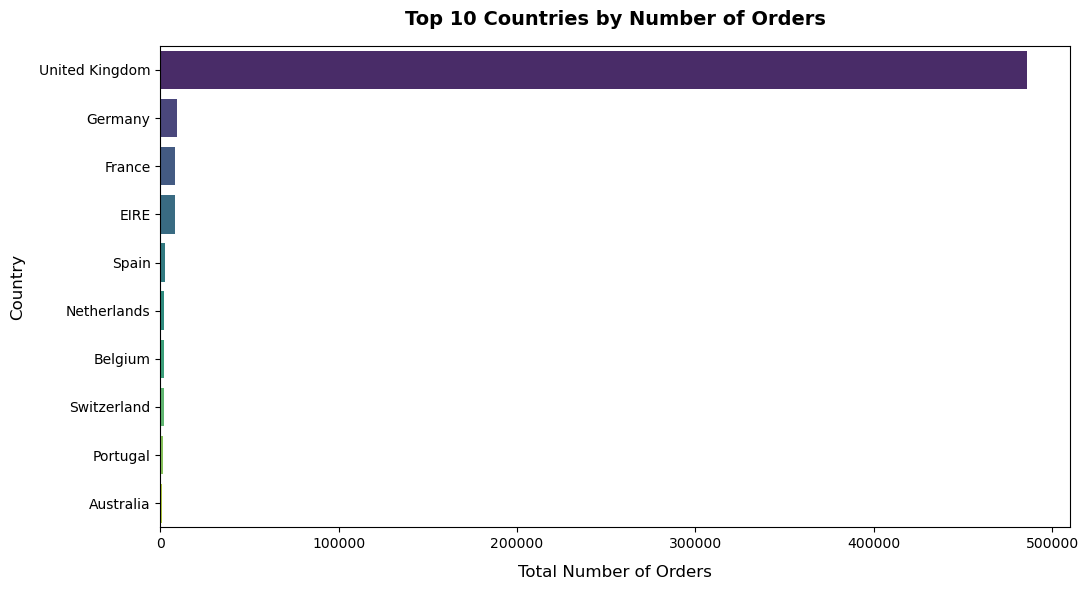

In [66]:
# 1. Get the top 10 countries by number of rows (orders)
top_10_countries = df_cleaned['country'].value_counts().head(10).reset_index()
top_10_countries.columns = ['country', 'order_count']

# 2. Set up the plotting grid using subplots
fig, ax = plt.subplots(figsize=(11, 6))

# 3. Create a horizontal bar chart so country names are completely readable and not overlapping
sns.barplot(
    data=top_10_countries, 
    x='order_count', 
    y='country', 
    ax=ax, 
    palette='viridis'
)

# 4. Add clean headers and titles
ax.set_title('Top 10 Countries by Number of Orders', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Total Number of Orders', fontsize=12, labelpad=10)
ax.set_ylabel('Country', fontsize=12, labelpad=10)

# 5. Format layout neatly and display
plt.tight_layout()
plt.show()

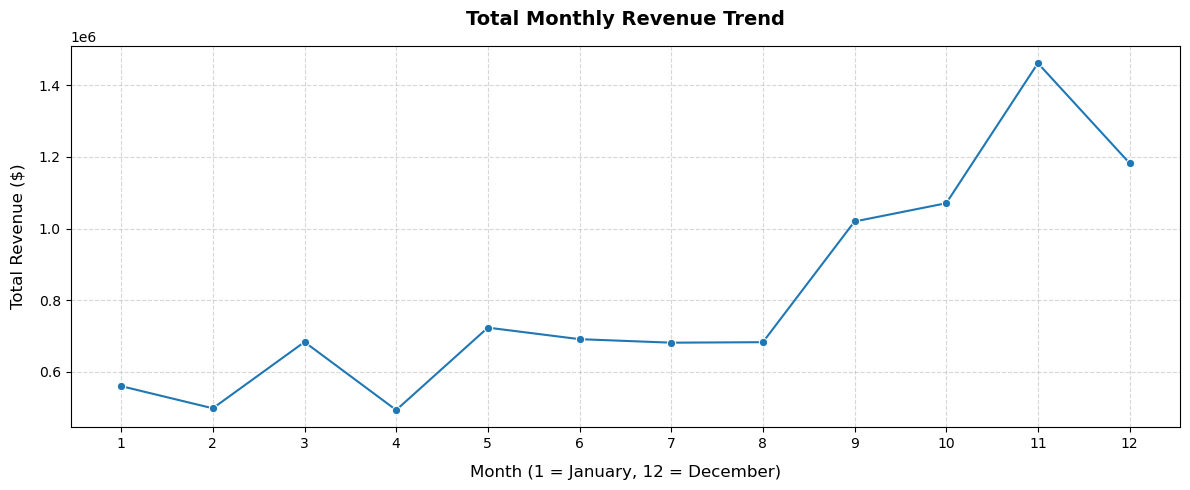

In [67]:
monthly_sales = df_cleaned.groupby('month')['total-sales'].sum().reset_index()

# 2. Sort by month number (1 to 12) so the line chart moves chronologically
monthly_sales = monthly_sales.sort_values(by='month').reset_index(drop=True)

# 3. Create the line chart using subplots
fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(
    data=monthly_sales, 
    x='month', 
    y='total-sales', 
    ax=ax, 
    marker='o',       
    color='#1f77b4'   
)

# 4. Standardize titles and ensure labels are fully readable
ax.set_title('Total Monthly Revenue Trend', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month (1 = January, 12 = December)', fontsize=12, labelpad=10)
ax.set_ylabel('Total Revenue ($)', fontsize=12, labelpad=10)

# 5. Force the X-axis to display every single month number explicitly
ax.set_xticks(range(1, 13))

# 6. Add a subtle grid to make reading values across the chart much easier
ax.grid(True, linestyle='--', alpha=0.5)

# 7. Optimize layout and display
plt.tight_layout()
plt.show()

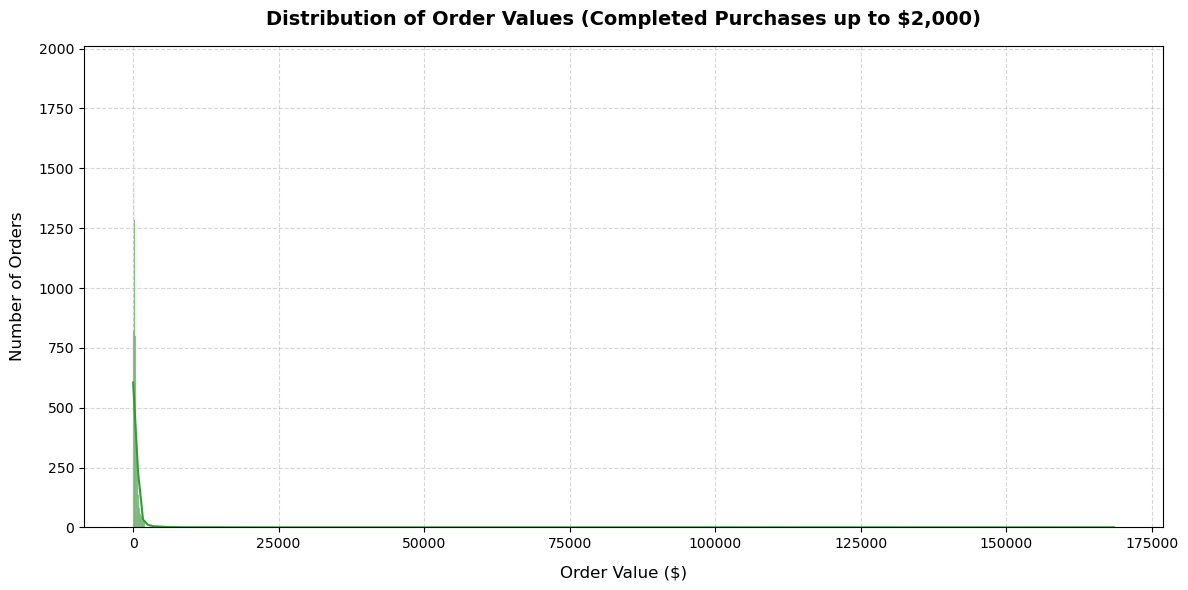

In [71]:
# 1. Calculate order totals from completed sales (revenue > 0)
order_totals = df_cleaned.groupby('invoice-no')['total-sales'].sum()
completed_orders = order_totals[order_totals > 0]

# 2. Initialize the plot layout using subplots
fig, ax = plt.subplots(figsize=(12, 6))

# 3. Create the histogram
# We pass 'completed_orders' directly as the data array without specifying columns!
sns.histplot(
    data=completed_orders, 
    bins=50, 
    binrange=(0, 2000), 
    kde=True,            
    color='#2ca02c',     
    ax=ax
)

# 4. Label and title the graph cleanly
ax.set_title('Distribution of Order Values (Completed Purchases up to $2,000)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Order Value ($)', fontsize=12, labelpad=10)
ax.set_ylabel('Number of Orders', fontsize=12, labelpad=10)

# 5. Add a grid for readability
ax.grid(True, linestyle='--', alpha=0.5)

# 6. Optimize layout and display
plt.tight_layout()
plt.show()

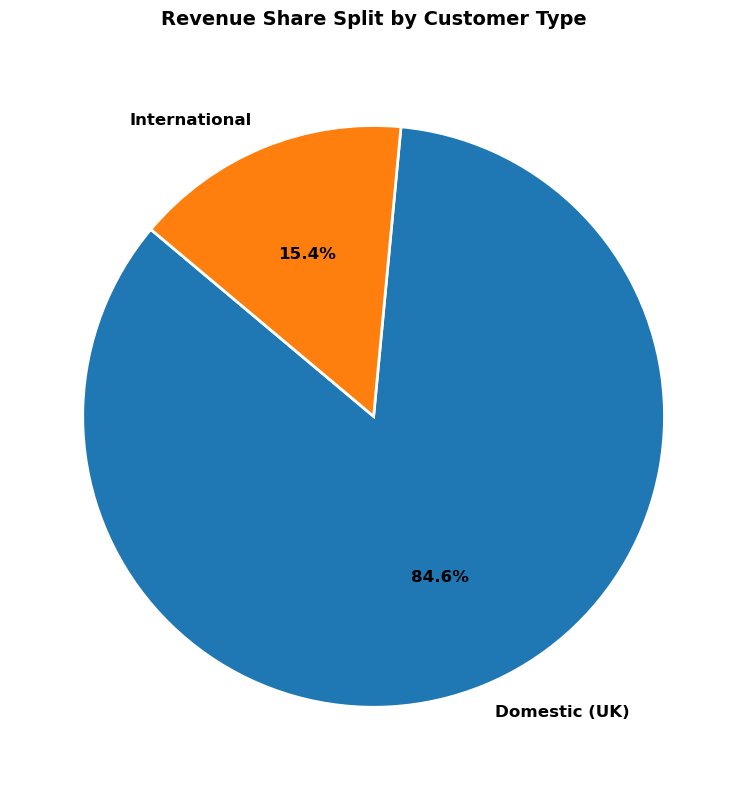

In [72]:
df_cleaned['customer-type'] = df_cleaned['country'].apply(
    lambda x: 'Domestic (UK)' if x == 'United Kingdom' else 'International'
)

# 2. Group by this new customer type and sum up the total sales revenue
# We filter for positive revenue (> 0) to ensure returns don't distort the market share split
revenue_by_type = df_cleaned[df_cleaned['total-sales'] > 0].groupby('customer-type')['total-sales'].sum().reset_index()

# 3. Initialize the plot layout using subplots
fig, ax = plt.subplots(figsize=(8, 8))

# 4. Create a clean pie chart
ax.pie(
    revenue_by_type['total-sales'], 
    labels=revenue_by_type['customer-type'], 
    autopct='%1.1f%%',          # Displays the exact percentage on the slices
    startangle=140,             # Rotates the chart for a clean aesthetic angle
    colors=['#1f77b4', '#ff7f0e'], # Sharp, contrasting corporate colors
    textprops={'fontsize': 12, 'weight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2} # Adds clean white borders between slices
)

# 5. Add a clear header title
ax.set_title('Revenue Share Split by Customer Type', fontsize=14, fontweight='bold', pad=20)

# 6. Optimize layout and display
plt.tight_layout()
plt.show()

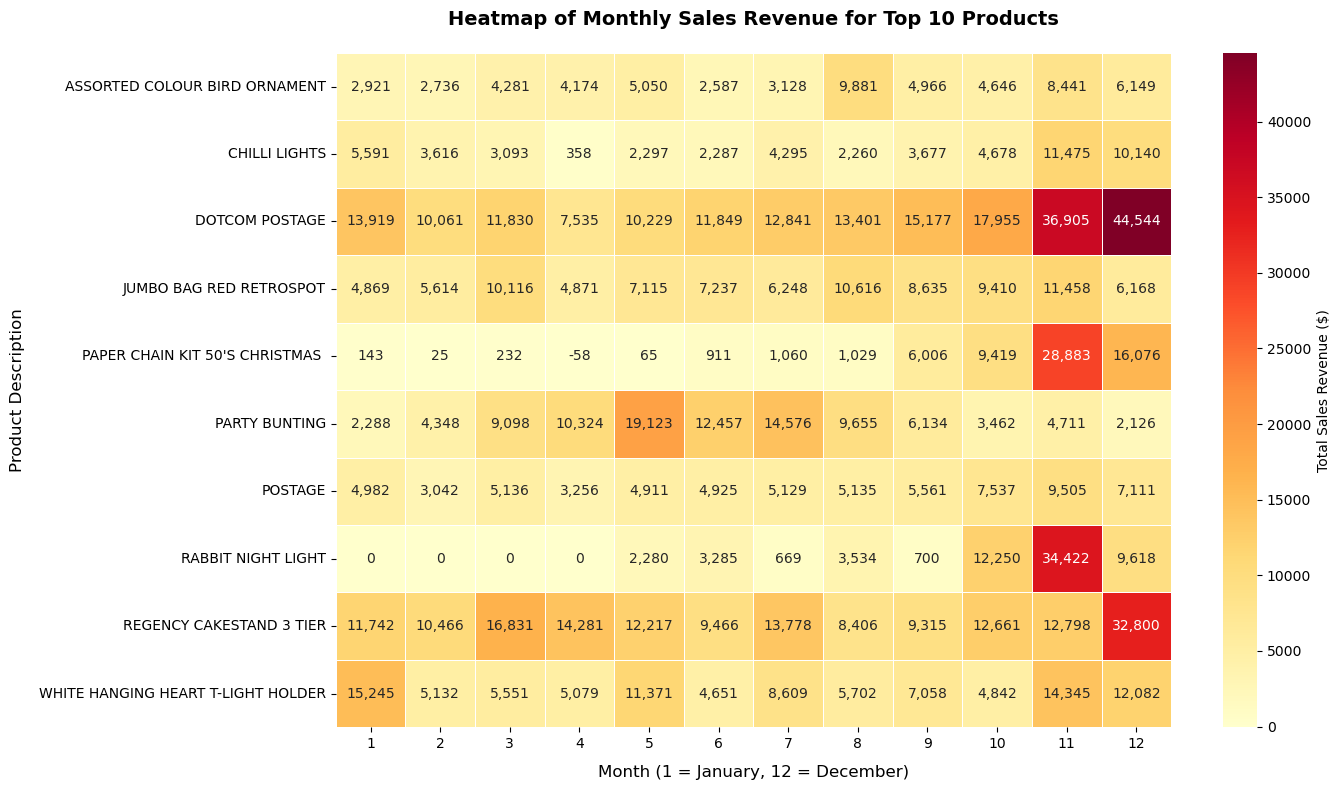

In [73]:
# 1. Find the top 10 products by total sales revenue to keep the heatmap clean and readable
top_10_product_names = df_cleaned.groupby('description')['total-sales'].sum().nlargest(10).index

# 2. Filter the dataframe to only include transactions for these top 10 products
df_top_products = df_cleaned[df_cleaned['description'].isin(top_10_product_names)]

# 3. Create a pivot table: products as rows, months (1-12) as columns, and sum of total-sales as values
heatmap_data = df_top_products.pivot_table(
    index='description', 
    columns='month', 
    values='total-sales', 
    aggfunc='sum'
).fillna(0) # Replace any months with no sales with 0

# 4. Initialize the plot layout using subplots
fig, ax = plt.subplots(figsize=(14, 8))

# 5. Generate the heatmap with a warm, intuitive color scheme
sns.heatmap(
    heatmap_data, 
    cmap='YlOrRd',       # Yellow to Orange to Red (darker red = higher sales)
    annot=True,         
    fmt=',.0f',          
    linewidths=0.5,      
    linecolor='white',
    cbar_kws={'label': 'Total Sales Revenue ($)'}, # Label the color scale bar
    ax=ax
)

# 6. Set descriptive titles and labels
ax.set_title('Heatmap of Monthly Sales Revenue for Top 10 Products', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Month (1 = January, 12 = December)', fontsize=12, labelpad=10)
ax.set_ylabel('Product Description', fontsize=12, labelpad=10)

# 7. Optimize layout and display
plt.tight_layout()
plt.show()